In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [ ]:
import pandas as pd
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=200, centers=3, random_state=42)
df = pd.DataFrame(X,columns=['Feature 1','Feature 2'])
print(df.head())

   Feature 1  Feature 2
0   6.505653   2.447003
1  -5.128943   9.836189
2  -6.891874  -7.777364
3  -8.327712  -8.287573
4  -7.468992  -6.030507


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

df['Cluster']=kmeans.labels_
print(df.head())

print("cluster centers:")
print(kmeans.cluster_centers_)

   Feature 1  Feature 2  Cluster
0   6.505653   2.447003        2
1  -5.128943   9.836189        0
2  -6.891874  -7.777364        1
3  -8.327712  -8.287573        1
4  -7.468992  -6.030507        1
cluster centers:
[[-2.65882129  8.95756821]
 [-6.74539381 -6.85144337]
 [ 4.63218228  2.10121377]]


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(x_scaled)
df['DBSCAN_Cluster'] = dbscan.labels_
print(df.head())
noise_points = df[df['DBSCAN_Cluster'] == -1]
print("Number of Noise Points:", len(noise_points))

   Feature 1  Feature 2  Cluster  DBSCAN_Cluster
0   6.505653   2.447003        2               0
1  -5.128943   9.836189        0               1
2  -6.891874  -7.777364        1               2
3  -8.327712  -8.287573        1               2
4  -7.468992  -6.030507        1               2
Number of Noise Points: 0


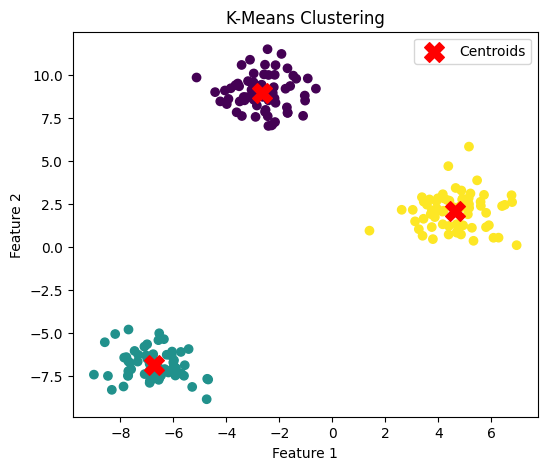

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(df['Feature 1'],df['Feature 2'],c=df['Cluster'],cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200,c='red',marker='X',label='Centroids')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
data={
    'Age':[22,25,30,40],
    'Salary':[30000,50000,60000,80000,10000],
    'City':['Delhi','Mumbai','Pune','Delhi','Mumbai'],
    'Purchased':[0,1,0,1,1],
}
df=pd.DataFrame(data)
print(df)